# MLP - Algoritmo Backpropagation

Profa  Silvia Moraes - Setembro/2025

Treinando o XOR com o algoritmo backpropagation. Exibindo as equacoes de reta e area de decisao.

In [46]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

Funcoes de Ativacao testadas

In [26]:
# Função de ativação sigmoide e sua derivada
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

In [27]:
# Função ReLU e sua derivada
def relu(x):
    return max(0, x)

def d_relu(x):
    return 1 if x > 0 else 0

Metodo para iniciar os pesos aleatoriamente

In [47]:
# Inicializa pesos aleatórios
def inicializa_pesos(linhas, colunas):
    return [[random.uniform(-1, 1) for _ in range(colunas)] for _ in range(linhas)]

Dados de entrada: XOR

In [29]:
# Dados da função XOR
entradas = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]
saidas_desejadas = [[0], [1], [1], [0]]

Definindo a rede e seus parametros

In [30]:
# Hiperparâmetros
n_entrada = 2
n_oculta = 2
n_saida = 1
taxa_aprendizado = 0.07
epocas = 10000

Criando a rede: pesos dos neuronios

In [39]:
# Inicializacao: Pesos (incluido bias)
W1 = inicializa_pesos(n_entrada, n_oculta)
W2 = inicializa_pesos(n_oculta, n_saida)
b1 = [random.uniform(-1, 1) for _ in range(n_oculta)]
b2 = [random.uniform(-1, 1) for _ in range(n_saida)]

print("Pesos - iniciais: ")
print("Pesos camada oculta (W1):")
print(b1)
for linha in W1:
    print(linha)

print("\nPesos camada de saída (W2):")
print(b2)
for linha in W2:
    print(linha)

Pesos - iniciais: 
Pesos camada oculta (W1):
[0.5154784324187573, -0.34795601524058983]
[0.22133733104459763, -0.7742243567112188]
[-0.9025438544134055, -0.8843674789864062]

Pesos camada de saída (W2):
[-0.5444899049302827]
[-0.29470959804056385]
[0.08308759897280837]


Fase de Treinamento da rede: procurando os pesos

In [48]:
# Treinamento
for epoca in range(epocas):
    erro_total = 0
    for x, y in zip(entradas, saidas_desejadas):
        # ===== Propagacao =====
        # Camada oculta
        z1 = [sum(x[i] * W1[i][j] for i in range(n_entrada)) + b1[j] for j in range(n_oculta)]
        a1 = [sigmoid(v) for v in z1]
        #a1 = [relu(v) for v in z1]

        # Camada de saída
        z2 = [sum(a1[j] * W2[j][k] for j in range(n_oculta)) + b2[k] for k in range(n_saida)]
        a2 = [sigmoid(v) for v in z2]
        #a2 = [relu(v) for v in z2]

        # ===== Retropagacao =====
        # Erro na saída
        erro = [y[k] - a2[k] for k in range(n_saida)]
        erro_total += sum(e**2 for e in erro)

        # Gradiente na saída
        delta2 = [erro[k] * d_sigmoid(z2[k]) for k in range(n_saida)]
        #delta2 = [erro[k] * d_relu(z2[k]) for k in range(n_saida)]

        # Gradiente na oculta
        delta1 = [
            d_sigmoid(z1[j]) * sum(delta2[k] * W2[j][k] for k in range(n_saida))
            #d_relu(z1[j]) * sum(delta2[k] * W2[j][k] for k in range(n_saida))
            for j in range(n_oculta)
        ]

        # Atualiza pesos W2 e bias b2
        for j in range(n_oculta):
            for k in range(n_saida):
                W2[j][k] += taxa_aprendizado * delta2[k] * a1[j]
        for k in range(n_saida):
            b2[k] += taxa_aprendizado * delta2[k]

        # Atualiza pesos W1 e bias b1
        for i in range(n_entrada):
            for j in range(n_oculta):
                W1[i][j] += taxa_aprendizado * delta1[j] * x[i]
        for j in range(n_oculta):
            b1[j] += taxa_aprendizado * delta1[j]

    # Mostra erro a cada 1000 épocas
    if epoca % 1000 == 0:
        print(f"Época {epoca}, Erro: {erro_total:.6f}")


Época 0, Erro: 0.027361
Época 1000, Erro: 0.021284
Época 2000, Erro: 0.017299
Época 3000, Erro: 0.014508
Época 4000, Erro: 0.012456
Época 5000, Erro: 0.010888
Época 6000, Erro: 0.009655
Época 7000, Erro: 0.008663
Época 8000, Erro: 0.007847
Época 9000, Erro: 0.007167


Modelo definido: pesos encontrados

In [50]:
print("Pesos - finais: ")
print("Pesos camada oculta (W1):")
print(b1)
for linha in W1:
    print(linha)

print("\nPesos camada de saída (W2):")
print(b2)
for linha in W2:
    print(linha)

Pesos - finais: 
Pesos camada oculta (W1):
[np.float64(6.248298273816979), np.float64(2.2677570926450397)]
[np.float64(-4.21255453701525), np.float64(-5.814338985807973)]
[np.float64(-4.225469118674771), np.float64(-5.881886591612311)]

Pesos camada de saída (W2):
[np.float64(-3.7993380358736)]
[np.float64(8.196951475780493)]
[np.float64(-8.48447180030741)]


Fase de Generalizacao: testando a rede com os pesos encontrados

In [51]:
# Testando a rede treinada
print("\nTestes finais (XOR):")
saidaRede=[]
for x in entradas:
    z1 = [sum(x[i] * W1[i][j] for i in range(n_entrada)) + b1[j] for j in range(n_oculta)]
    a1 = [sigmoid(v) for v in z1]

    z2 = [sum(a1[j] * W2[j][k] for j in range(n_oculta)) + b2[k] for k in range(n_saida)]
    a2 = [sigmoid(v) for v in z2]

    print(f"{x} -> {a2[0]:.4f}")
    saidaRede.append(a2[0])




Testes finais (XOR):
[0, 0] -> 0.0353
[0, 1] -> 0.9615
[1, 0] -> 0.9613
[1, 1] -> 0.0486


Necessidade de Pos-processamento pois a saida eh continua

In [43]:
#Pos processamento
s=[]
for i in range(len(saidaRede)):
    if saidaRede[i] >= 0.5:
        s.append(1)
    else:
        s.append(0)

print("\nPos processamento: ")
for i in range(len(s)):
    print(s[i])



Pos processamento: 
0
1
1
0


Plotando as equacoes de reta definidas pelos neuronios da camada oculta

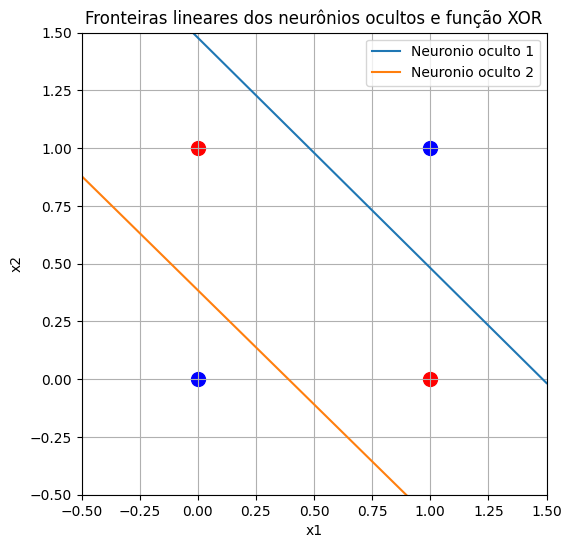

In [52]:
# Dados XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

# Função para desenhar a reta: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
def reta(w, b, x_range):
    if w[1] != 0:
        return -(w[0]*x_range + b)/w[1]
    else:
        return np.full_like(x_range, -b)  # reta vertical

# Criando gráfico
plt.figure(figsize=(6,6))
x_range = np.linspace(-0.5, 1.5, 200)

# Plota as retas de decisão dos neurônios ocultos
for j in range(n_oculta):
    y_vals = reta([W1[0][j], W1[1][j]], b1[j], x_range)
    plt.plot(x_range, y_vals, label=f'Neuronio oculto {j+1}')

# Plota pontos XOR
for i, point in enumerate(X):
    color = 'red' if y[i]==1 else 'blue'
    plt.scatter(point[0], point[1], color=color, s=100)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Fronteiras lineares dos neurônios ocultos e função XOR")
plt.legend()
plt.grid(True)
plt.show()


Plotando a regiao de decisao correspondente a camada de saida

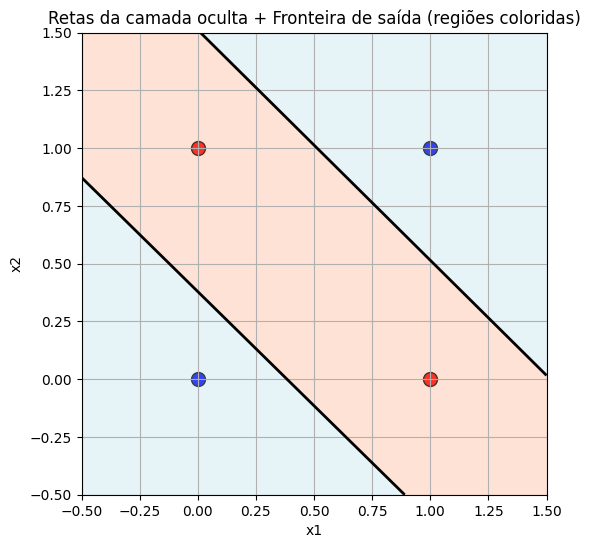

In [53]:
# Forward pass
def forward(X):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return a2

# Função sigmoide
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Criando gráfico
plt.figure(figsize=(6,6))
#x_range = np.linspace(-0.5, 1.5, 200)

# Pontos XOR
for i, point in enumerate(X):
    color = 'red' if y[i]==1 else 'blue'
    plt.scatter(point[0], point[1], color=color, s=100, edgecolor='black')

# ===== Regiões de saída =====
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300),
                     np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
saida = forward(grid).reshape(xx.shape)

# Fundo colorido
plt.contourf(xx, yy, saida, levels=[0,0.5,1], colors=['#ADD8E6','#FFA07A'], alpha=0.3)
# Contorno da fronteira de decisão
plt.contour(xx, yy, saida, levels=[0.5], colors='black', linewidths=2)
# ==========================

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Retas da camada oculta + Fronteira de saída (regiões coloridas)")
plt.grid(True)
plt.show()
